# Maskininlärning labb 2 
## CNN Tolkningsbarhet
*Adrian Söderberg Skog*
**AIMG25**
### Introduktion

Konvolutionella neurala nätverk används i stor utsträckning för bildklassifiering, men beslutsprocssen kan vara svår att tolka. Tolkningsbarhetsforskning syftar till att undersöka hur dessa modeller kommer fram till sina prediktioner och vilka delar av indata som påverkar resultatet. 

I denna uppgift används ResNet18 med förtränade vikter från ImageNet för att analysera tre olika klasser. För varje klass testas ett positivt exempel, där objektet finns representerat i bilden, samt ett negativt exempel där objektet saknas men något som liknar det finns representerat.
 
Genom att använda class attribution maps kan visualiseringar göras som visar vilka delar av en bild modellen fokuserar på vid klassifiering. I detta experiment undersöks hur detta fokus skiljer sig åt mellan korrekta och felaktiga prediktioner. Detta kan ge en förståelsee för vilka visuella egenskaper modellen använder vid klassifiering. 

In [17]:
from cam import imgNetPath, image_paths, test_images, get_model_and_weights, load_class_index

model, weights = get_model_and_weights()
class_index = load_class_index(imgNetPath)

### Data
Datan som som används i projektet består av en JSON-fil med ImageNet-klasser och tillhörande index, innehållande totalt 1000 klasser. Utöver detta används sex testbilder som valts ut för att möjliggöra en riktad analys av modellens beteende. 

Tre klasser analyseras, Yorkshire terrier, vithaj och lodjur. I de tre bilderna med positiva exempel finns en av dessa klasser representerad i varje bild. I de tre bilderna med negativa exempel finns klasserna inte representerad, istället finns något med liknande visuella egenskaper som potentiellt kan förvirra modellen.

De negativa exemplena har valts med avsikt att testa modellens begränsningar. 
- **Yorkshiree terrier:**
    En bild på chewbacca från star wars används som negativt exempel. Eftersom han tillhör en fiktiv art, "Wookies", som inte finns representerad i ImageNet är hypotesen att modellen kommer att klassifiera honom som ett liknande djur, där hundraser som yorkshire terrier eller shih tzu ligger visuellt nära. Detta exempel gör det möjligt att undersöka hur modellen förlitar sig på textur och visuella likheter för att hitta en nära klass.

- **Vithaj:**
    En bild på en pighaj används som negativt exempel. ImageNet innehåller flera hajarter såsom vithaj, tigerhaj och hammarhaj, dock inte pighaj. Pighajen delar vissa likheter med vithajen men skiljer sig i storlek och proportioner. Detta exempel används för att se hur väl modellen kan generalisera till närbesläktade klasser.

- **Lodjur:**
    En bild på en pälsjacka tillverkad av lodjurspäls används som negativt exempel. Pälsjacka finns repressenterat som en klass i imageNet. För att utmana modellen ytterligare är bilden därför kroppad så att konturer och form döljs och därmed tvingar modellen förlita sig på textur. Detta gör det möjligt att undersöka huruvida detta är tillräckligt med information för att modellen skall kunna skilja objektet från djuret. 

#### Bilder

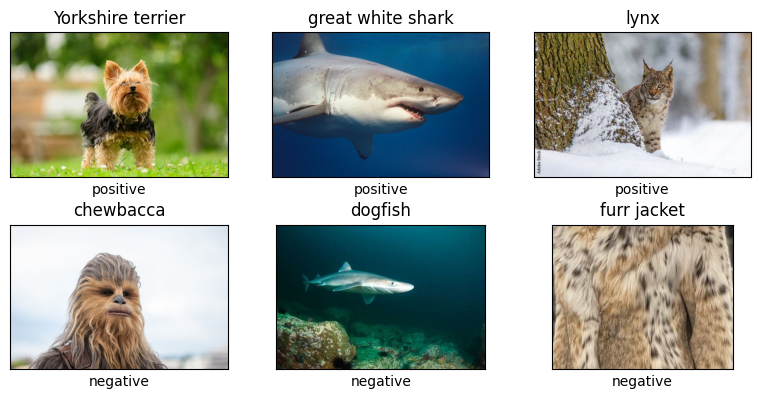

In [18]:
from cam import plot_test_images

plot_test_images(test_images)


### Metod

För utförandet används modellen ResNet18 som är förtränad på ImageNet-datasetet. Denna modell valdes främst för att den erbjuder en bra balans mellan hög noggrannhet och låg beräkningskostnad. Den är snabbare och lättare än andra alternativ som VGG19 och ResNet50, och kan köras på vanlig CPU, samtidigt som den presterar bättr än äldre modeller som Alexnet.

För att visualisera och analysera modellens beslut används biblioteket Torchcam som innehåller methoder för att generera class attribution maps. I denna analys används LayerCam då den pålitligt kan generera attribution maps från samtliga lager. 

Alla nödvändiga funktioner för implementationen finns i filen cam.py. Analysen följer följande arbetsflöde. 
1. Först hämtas modellen och vikter, testbilder och JSON-filen med klassindex och klassnamn laddas in. 
2. Bilderna förbehandlas och omvandlas till tensorer. 
3. En forward pass genomförs där modellen tar indata-tensorn och producerar en utdata-tensor med logits. 
4. De fem högsta logit-värdena extraheras och omvandlas till sannolikheter. Motsvarand klassnamn hämtas från JSON-filen.
5. Attribution maps genereras från det sista lagret (layer 4) med hjälp av layerCam. Dessa normaliseras och skalas om innan de överlagras på orginalbilden för visualisering. 
6. För Lodjursklassen görs även en djupare analys, där activation maps från alla 4 lager extraheras för att analysera av utvecklingen genom lagrena.  

### Resultat

#### Klass 1: Yorkshire terrier

Den positiva bilden klassificeras korrekt med ca 90% konfidens. Aktiveringsfokus ligger mestadels på huvud och övre del av, vilket indikerar att modellen använder relevanta visuella egenskaper som ansiktsproportioner, pälstextur och kroppsform för klassificeringen. 
Den negativa bilden klassifieras felaktigt som yorkshire terrier med ca. 87% konfidens vilket är nästan lika högt som den positiva bilden. Aktivering ligger främst på ansikte, vilket tyder på att egenskaper som ansiktsstruktur och pälstextur är mest avgörande för klassificeringen.

Samtliga top 5 prediktioner för den positiva bilden är nära besläktade med den korrekta klassen. Yorkshire terrier först följt av andra liknande hundraser. Den negativa bilden följer ett liknande mönster där de tre högsta är samma som för den positiva. Även konfidensen för dem är väldigt lika. Den femte högsta prediktionen för den negativa bilden är dock "Kite" (drake) med en konfidens på 0,5%. Även om detta är ett lågt värde är det intressant då det tyder på att modellen hittar visuella egenskaper som delas med andra objekt.

In [19]:
from cam import prediction_summary
prediction_summary(class_index, model, weights, test_images[0::3])



Class label: Yorkshire terrier
type: positive
Predicted class: Yorkshire_terrier, Confidence: 0.8976673483848572 

top 5:
Yorkshire_terrier : 0.8976673483848572
Australian_terrier : 0.06295273452997208
silky_terrier : 0.03651244193315506
Norwich_terrier : 0.0010992749594151974
Tibetan_terrier : 0.000298663362627849


Class label: chewbacca
type: negative
Predicted class: Yorkshire_terrier, Confidence: 0.8684734106063843 

top 5:
Yorkshire_terrier : 0.8684734106063843
Australian_terrier : 0.06777776777744293
silky_terrier : 0.021159635856747627
Tibetan_terrier : 0.008419969119131565
kite : 0.005341013893485069


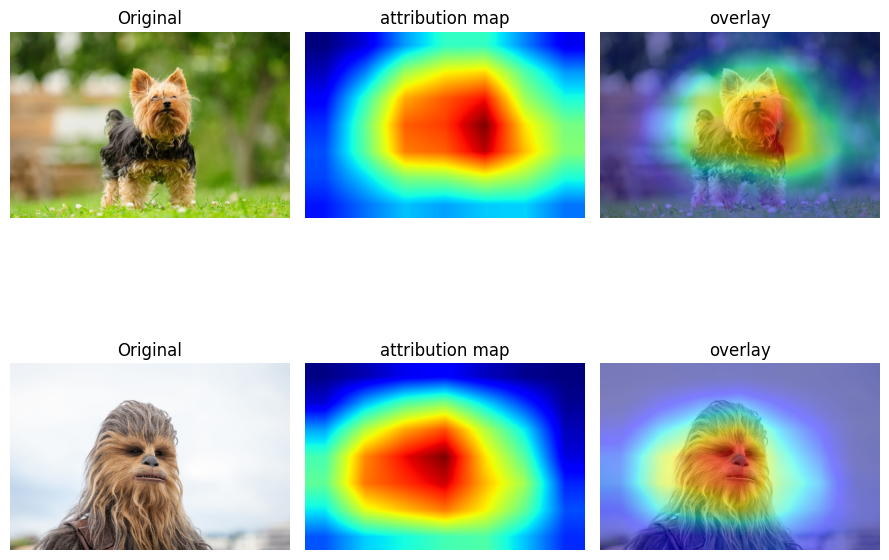

In [20]:
from cam import plot_cam
plot_cam(image_paths[0::3], model, weights)

#### Klass 2: Vithaj

Vithajen klassificeras korrekt med ca 95% konfidens. Aktiveringskartan visar att fokus ligger mest på ansiktsstrukturerna, mun, ögon, nos och även en del på sidofenan. Observerar man top 5 logits framgår det att de högst rankade är samtliga hajarter som finns med i ImageNet, följt av en fisk och ett annat vattenlevande däggdjur. Tigerhajen som ligger närmast i utseende har fått ca 4% och de tre andra har extremt låga värden. Detta tyder på att väsentliga visuella egenskaper, som är typiska för vithaj och i viss mån andra hajarter, identifieras av modellen.

Den negativa bilden på en pighaj klassifieras felaktigt som en tigerhaj med ca 45% konfidens. Modellen visar större osäkerhet den här gången och fördelar sannolikheten mellan olika klasser där Stör, som är en fisk, når 30%. Resterande inkluderar ål, hammarhaj och coho med sannolikheter mellan 4-9% vardera. Gemensamt för dessa klasser är att de är vattenlevande djur, vilket talar för att modellen identifierar mer generella egenskaper kopplade till marina miljöer snarare än artkarraktäristiska egenskaper.
Aktiveringskartan visar också ett mer utspritt fokus över hela hajens kropp med mest koncentration på undersidan mellan sidfenorna. Detta kan vara en indikation på att modellen förlitar sig på mer övergripande visuella drag jämfört med den positiva bilden där fokuset var mer koncentrerat på specifika anatomiska strukturer. 

In [21]:
prediction_summary(class_index, model, weights, test_images[1::3])



Class label: great white shark
type: positive
Predicted class: great_white_shark, Confidence: 0.9551841616630554 

top 5:
great_white_shark : 0.9551841616630554
tiger_shark : 0.04468819499015808
hammerhead : 0.00011906041618203744
sturgeon : 8.252151928900275e-06
dugong : 2.0457430593978643e-07


Class label: dogfish
type: negative
Predicted class: tiger_shark, Confidence: 0.48420557379722595 

top 5:
tiger_shark : 0.48420557379722595
sturgeon : 0.3004901111125946
eel : 0.09003079682588577
hammerhead : 0.053336191922426224
coho : 0.04101785644888878


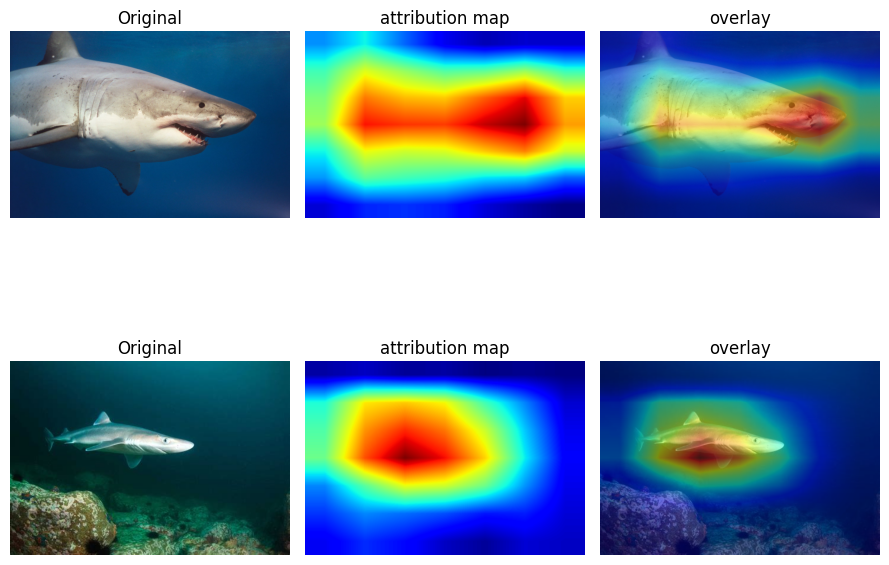

In [22]:
plot_cam(image_paths[1::3], model, weights)

#### Klass 3: Lodjur

Lodjuret klassificeras korrekt med 99% konfidens vilket är högst av alla de testade bilderna. Samtliga av top 5 prediktioner utgörs av kattdjur. aktivringskartan visar att fokus delvis ligger på ansiktet och övre kroppen men en aning förskutet till sidan så att en betydande del av bakgrunden är med. Detta kan indikera att den lyckas fånga kontur, pälsens textur, ansiktets anatomi. Det kan också vara möjligt att den tar hjälp av kontextuell information som snö för att stödja sin prediktion.

Den negativa bilden blev felaktigt klassificerad som en hyena med 46% konfidens och pälsjacka hamnade strax under med 43%. Övriga prediktioner i top 5 inkludrar andra kattdjur dock inte lodjur. 
Bilden är medvetet beskuren för att dölja mycket av jackans form även om vissa linjer kan ge ledtrådar. Detta visar att modellen har svårare att göra korrekta bedömningar när information om form är begränsad. 

Aktiveringskartan visar att fokuset är koncentrerat till ett specifikt område i pälsen. Även om hyenor och lodjur inte är lika i övrigt kan det finnas vissa gemensamma mönster i pälsen. Att modellen också tilldelade relativt hög sannolikhet till klassn pälsjacka tyder dock på att modellen även identifierar egenskaper som inte är relaterade till djur. 

In [23]:
prediction_summary(class_index, model, weights, test_images[2::3])



Class label: lynx
type: positive
Predicted class: lynx, Confidence: 0.9916083216667175 

top 5:
lynx : 0.9916083216667175
tiger_cat : 0.0030357118230313063
tabby : 0.0016475721495226026
snow_leopard : 0.0015335401985794306
leopard : 0.0010887387907132506


Class label: furr jacket
type: negative
Predicted class: hyena, Confidence: 0.46590492129325867 

top 5:
hyena : 0.46590492129325867
fur_coat : 0.43210843205451965
cheetah : 0.025522921234369278
snow_leopard : 0.02450001798570156
leopard : 0.015569817274808884


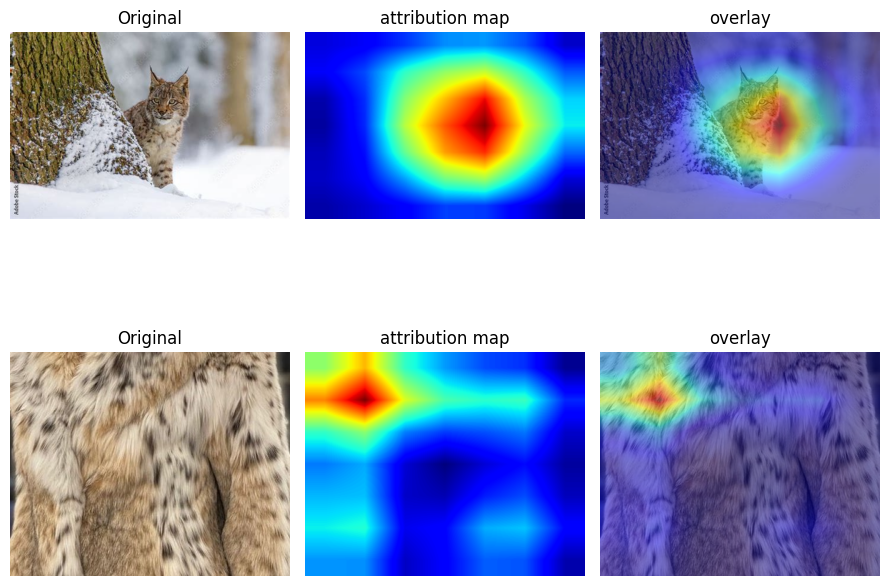

In [24]:
plot_cam(image_paths[2::3], model, weights)

#### Lageranalys

Vid analys av samtliga fyra lager för den positiva lodjursbilden framgår en tydlig utveckling. I det första lagret är aktiveringarna många och små, men koncentrerade på viktiga delar av objektet. Här fångas främst enkla egenskaper som linjer, kanter och kontraster. Det tycks främst vara fördelat på ansikte samt på konturen av djuret. 

I lager två är aktiveringarna större och mer sammanhängande. Fokuset är på mer komplexa strukturer som öga, nos, kind och öra. Det syns även här hur en viss aktivering följer konturen. Detta indikerar på att modellen kombinerar de enklare egenskaperna till mer meningsfulla former. 

I terdje lagret är aktiveringen mer koncentrerad på ett specifikt område mellan öga och öra. Detta kan tolkas som att lagret är mer specialicerat på andra specifika egenskaper än föregående lager. 

I fjärde lagret syns ett globalt fokus på hela djuret vilket tyder på att modellen har satt ihop till en mer komplett representation av objektet.

Sammanfattningsvis visar analysen en progression från lågnivåegenskaper i det första lagret till mer komplexa och klasspecifika representationer i de senare lagren. Detta är i linje med hur konvolutionella nätverk generellt är uppbyggda, där enkla visuella mönster successivt kombineras till mer meningsfulla repressentationer. 

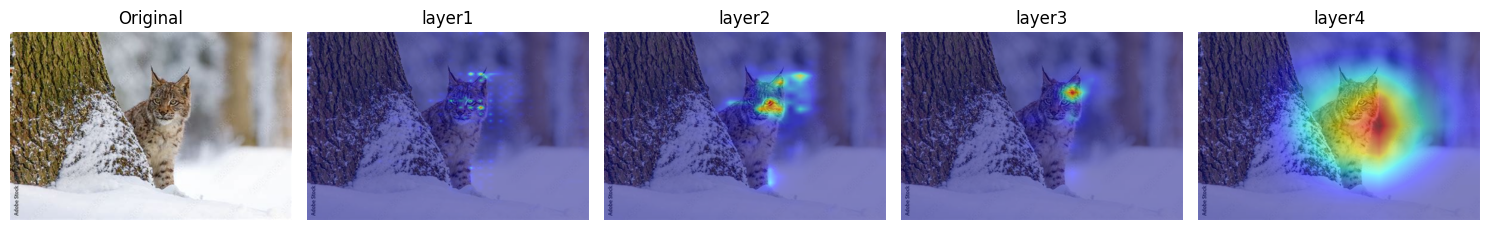

In [26]:
from cam import plot_layers
plot_layers(image_paths[2], model, weights)

### Disskusion

Experimentet visar att resnet18 modellen effektivt kan göra korrekta prediktioner med hög konfidens när objektet är tydligt pressentrat i bilden och klassen finns representerad i ImageNet. 
När klassen inte finns repressenterad lyckas modellen i viss utsträckning generalisera till närliggande klasser, dock med större osäkerhet och sannolikhterna mer fördelade mellan olika klasser. 
Modellen verkar prestera bäst när tillgång till information om form, proportioner, anatomisk struktur samt textur finns tillgänglig men lyckas till viss del identifiera förmål, om dock med lägre säkerhet, även när informationen är begränsad.